# Light Curve Viewer
Reads and plots the merged pipeline output for a given target and observation night.

In [6]:
# ── Parameters ─────────────────────────────────────────────────────────────────
# Edit these two values before running the notebook

TARGET   = "2001_EC"     # Name of the target folder
NIGHT    = "26_03_01"   # Observation night folder (e.g. '2024-07-15')
MAIN_DIR = "data/"            # Path to the main folder containing target subfolders

In [2]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [7]:
# ── Locate the merged data file ────────────────────────────────────────────────

night_dir   = os.path.join(MAIN_DIR, TARGET, NIGHT)
merged_file = os.path.join(night_dir, "pipelineout_datasubset_all.dat")

if not os.path.isfile(merged_file):
    sys.exit(
        f"Merged file not found:\n  {merged_file}\n"
        "Run merge_pipeline_dat.py first, or check TARGET / NIGHT / MAIN_DIR."
    )

print(f"Reading: {merged_file}")

Reading: data/2001_EC/26_03_01/pipelineout_datasubset_all.dat


In [8]:
# ── Load data ──────────────────────────────────────────────────────────────────
# The header line starts with '#', so we strip that character for clean column names

df = pd.read_csv(merged_file, sep="\t", comment=None, header=0)

# Strip the leading '#' from the first column name
df.columns = [c.lstrip("#").strip() for c in df.columns]

print(f"Loaded {len(df)} rows.")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 474 rows.
Columns: ['', 'Label', 'BJD_TDB', 'rel_flux_T1', 'rel_flux_err_T1']


,,Label,BJD_TDB,rel_flux_T1,rel_flux_err_T1
0,1,K01E00C-S001-R001-C001-R_out.fits,2.461102e+06,0.282673,0.010274
1,2,K01E00C-S001-R001-C002-R_out.fits,2.461102e+06,0.287690,0.010401
2,3,K01E00C-S001-R001-C003-R_out.fits,2.461102e+06,0.299098,0.010838
3,4,K01E00C-S001-R001-C004-R_out.fits,2.461102e+06,0.292461,0.010454
4,5,K01E00C-S001-R001-C005-R_out.fits,2.461102e+06,0.270790,0.010053


In [9]:
# ── Quick sanity check ─────────────────────────────────────────────────────────

required_cols = ["BJD_TDB", "rel_flux_T1", "rel_flux_err_T1"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected column(s): {missing}\nFound: {list(df.columns)}")

bjd  = df["BJD_TDB"]
flux = df["rel_flux_T1"]
err  = df["rel_flux_err_T1"]

print(f"BJD_TDB    : {bjd.min():.6f}  →  {bjd.max():.6f}")
print(f"rel_flux_T1: {flux.min():.6f}  →  {flux.max():.6f}")
print(f"Median flux error: {err.median():.6f}")

BJD_TDB    : 2461101.663736  →  2461101.908516
rel_flux_T1: 0.229892  →  0.324752
Median flux error: 0.009354


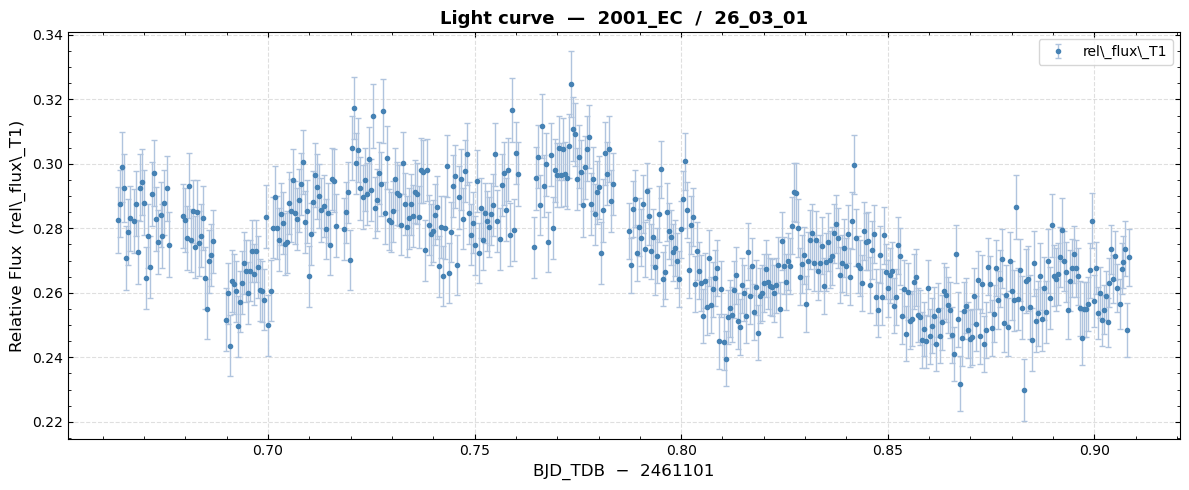

In [10]:
# ── Plot ───────────────────────────────────────────────────────────────────────

# Offset the BJD axis to avoid long numbers on the x-axis tick labels
bjd_offset = int(bjd.min())
bjd_plot   = bjd - bjd_offset

fig, ax = plt.subplots(figsize=(12, 5))

ax.errorbar(
    bjd_plot, flux, yerr=err,
    fmt="o",
    markersize=3,
    color="steelblue",
    ecolor="lightsteelblue",
    elinewidth=1,
    capsize=2,
    linewidth=0,
    label="rel\_flux\_T1"
)

ax.set_xlabel(f"BJD_TDB  −  {bjd_offset}", fontsize=12)
ax.set_ylabel("Relative Flux  (rel\_flux\_T1)", fontsize=12)
ax.set_title(
    f"Light curve  —  {TARGET}  /  {NIGHT}",
    fontsize=13, fontweight="bold"
)

ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.grid(visible=True, which="major", linestyle="--", alpha=0.4)
ax.legend(fontsize=10)

fig.tight_layout()
plt.show()